In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input


In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/paramaggarwal
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images
/kaggle/input/notebooks
/kaggle/input/notebooks/sahandakramipour


In [7]:
import os

dataset_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset"

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

Folder: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset
Folders: ['images']
Files: ['styles.csv']
--------------------------------------------------
Folder: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images
Folders: []
Files: ['31973.jpg', '30778.jpg', '19812.jpg', '22735.jpg', '38246.jpg']
--------------------------------------------------


In [8]:
import pandas as pd

csv_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/styles.csv"

df = pd.read_csv(csv_path, on_bad_lines="skip")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


Image Path: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images/15970.jpg


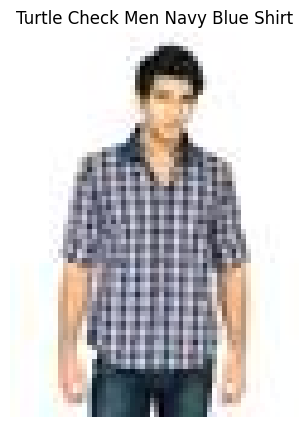

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Image folder path
image_folder = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images"

# Get first product ID
image_id = str(df.iloc[0]["id"]) + ".jpg"

# Create image path
image_path = os.path.join(image_folder, image_id)

print("Image Path:", image_path)

# Open image
img = Image.open(image_path)

# Display image
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(df.iloc[0]["productDisplayName"])
plt.show()

In [10]:
import os

print(os.path.exists(image_path))

True


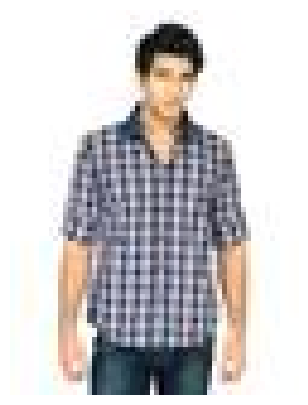

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
!pip install -q transformers torch torchvision pillow

In [16]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import os
import pandas as pd

In [17]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("✅ CLIP model loaded successfully!")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP model loaded successfully!


In [19]:
import torch
from PIL import Image
import os

image_folder = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images"

# Check only the first image
image_id = str(df.iloc[0]["id"]) + ".jpg"
image_path = os.path.join(image_folder, image_id)

print("Image Path:", image_path)
print("File Exists:", os.path.exists(image_path))

image = Image.open(image_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    features = model.get_image_features(**inputs)

print(features.shape)

Image Path: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images/15970.jpg
File Exists: True


AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'shape'

In [20]:
import torch
from PIL import Image
import os

image_folder = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images"

image_id = str(df.iloc[0]["id"]) + ".jpg"
image_path = os.path.join(image_folder, image_id)

image = Image.open(image_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model.get_image_features(**inputs)

print(type(outputs))
print(outputs)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.2177,  0.2518, -0.0492,  ..., -0.4101,  0.2336, -0.1099],
         [-0.1033,  0.1412, -0.5139,  ..., -0.2201,  0.2273,  0.4171],
         [-0.1385,  0.2368, -0.3497,  ..., -0.2035,  0.3045,  0.1925],
         ...,
         [-0.1182, -0.0567, -0.1738,  ..., -0.0322, -0.1303,  0.3330],
         [ 0.2015, -0.0357, -0.0906,  ...,  0.1478,  0.1543, -0.1910],
         [-0.0411,  0.0619, -0.4644,  ..., -0.4169,  0.0404, -0.0446]]]), pooler_output=tensor([[ 4.5575e-02,  2.5345e-01, -1.2212e-01,  3.6836e-02, -1.0668e-01,
          1.0584e-01, -5.6170e-02, -2.2421e-01,  2.5048e-01,  1.3485e-01,
          2.0783e-01,  4.4575e-01,  6.3402e-01,  4.6300e-01, -6.3646e-01,
          2.6845e-01,  1.4176e+00,  3.4850e-01,  2.4771e-01,  6.5101e-02,
          5.4763e-01, -3.8212e-01,  7.6502e-01, -6.0744e-01, -1.8963e-01,
          4.2901e-01,  3.1016e-01, -3.5763e-01, -6.1319e-02, 

In [21]:
with torch.no_grad():
    outputs = model.get_image_features(**inputs)

image_embedding = outputs.pooler_output

print(type(image_embedding))
print(image_embedding.shape)

<class 'torch.Tensor'>
torch.Size([1, 512])


In [22]:
import numpy as np
from tqdm import tqdm

image_embeddings = []
image_paths = []

for idx, row in tqdm(df.iterrows(), total=len(df)):

    image_id = str(row["id"]) + ".jpg"
    image_path = os.path.join(image_folder, image_id)

    # Check if image exists
    if os.path.exists(image_path):

        image = Image.open(image_path).convert("RGB")

        inputs = processor(
            images=image,
            return_tensors="pt"
        )

        with torch.no_grad():
            output = model.get_image_features(**inputs)

        # Get 512 dimensional vector
        embedding = output.cpu().numpy()

        image_embeddings.append(embedding[0])
        image_paths.append(image_path)

  0%|          | 0/44424 [00:00<?, ?it/s]


AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'cpu'

In [24]:
import numpy as np
from tqdm import tqdm
from PIL import Image
import os
import torch

image_embeddings = []
image_paths = []

for idx, row in tqdm(df.iterrows(), total=len(df)):

    image_id = str(row["id"]) + ".jpg"
    image_path = os.path.join(image_folder, image_id)

    # Check image exists
    if os.path.exists(image_path):

        image = Image.open(image_path).convert("RGB")

        # Convert image for CLIP
        inputs = processor(
            images=image,
            return_tensors="pt"
        )

        with torch.no_grad():
            output = model.get_image_features(**inputs)

        # Extract 512 dimensional embedding
        embedding = output.pooler_output.cpu().numpy()

        # Store embedding and path
        image_embeddings.append(embedding[0])
        image_paths.append(image_path)

print("Total embeddings created:", len(image_embeddings))
print("Total image paths stored:", len(image_paths))

100%|██████████| 44424/44424 [1:11:53<00:00, 10.30it/s]

Total embeddings created: 44419
Total image paths stored: 44419


In [25]:
import numpy as np

image_embeddings = np.array(image_embeddings).astype("float32")

print(image_embeddings.shape)

(44419, 512)


In [26]:
import faiss

faiss.normalize_L2(image_embeddings)

print("Embeddings normalized successfully")

ModuleNotFoundError: No module named 'faiss'

In [27]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 67.9 MB/s eta 0:00:00:00:0100:01


In [28]:
import faiss

faiss.normalize_L2(image_embeddings)

print("Embeddings normalized successfully")

Embeddings normalized successfully


In [29]:
dimension = image_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(image_embeddings)

print("Total products in FAISS index:", index.ntotal)

Total products in FAISS index: 44419


In [30]:
query = "blue casual shirt"

text_inputs = processor(
    text=[query],
    return_tensors="pt",
    padding=True
)

with torch.no_grad():
    text_output = model.get_text_features(**text_inputs)

text_embedding = text_output.pooler_output.cpu().numpy()

print(text_embedding.shape)

(1, 512)


In [31]:
faiss.normalize_L2(text_embedding)

print("Text embedding normalized")

Text embedding normalized


In [32]:
k = 5   # number of results

scores, indices = index.search(
    text_embedding,
    k
)

print("Matching product indexes:")
print(indices)

Matching product indexes:
[[10319 41094  4646 24159 34284]]


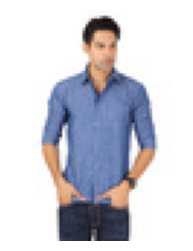

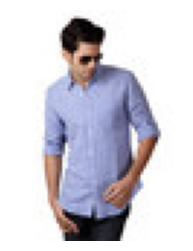

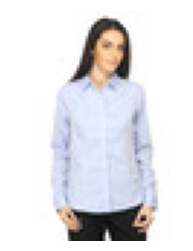

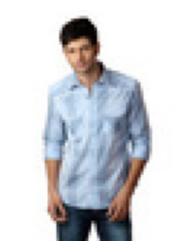

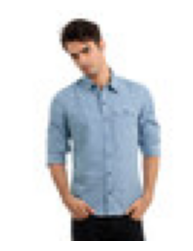

In [33]:
import matplotlib.pyplot as plt

for idx in indices[0]:

    img = Image.open(image_paths[idx])

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [34]:
print(text_embedding.shape)

(1, 512)


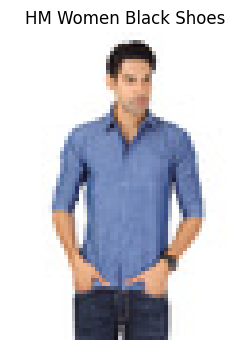

Product ID: 56992
Product Name: HM Women Black Shoes
-------------------------


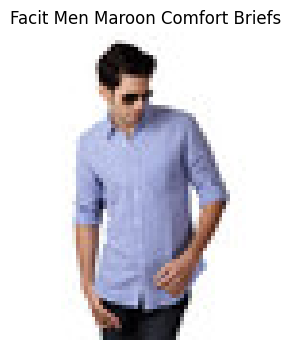

Product ID: 15904
Product Name: Facit Men Maroon Comfort Briefs
-------------------------


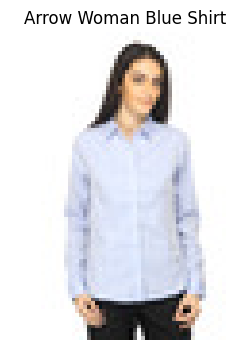

Product ID: 32393
Product Name: Arrow Woman Blue Shirt
-------------------------


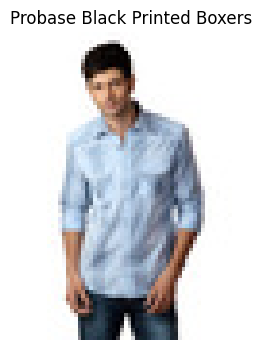

Product ID: 53557
Product Name: Probase Black Printed Boxers
-------------------------


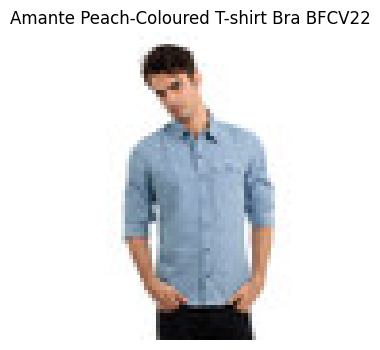

Product ID: 53498
Product Name: Amante Peach-Coloured T-shirt Bra BFCV22
-------------------------


In [35]:
import matplotlib.pyplot as plt

for idx in indices[0]:

    product_id = df.iloc[idx]["id"]
    product_name = df.iloc[idx]["productDisplayName"]

    img = Image.open(image_paths[idx])

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(product_name)
    plt.show()

    print("Product ID:", product_id)
    print("Product Name:", product_name)
    print("-------------------------")

In [36]:
print(type(model))

<class 'transformers.models.clip.modeling_clip.CLIPModel'>
